<a href="https://colab.research.google.com/github/gilberto7martinezr-spec/AssignmentsAF2_Data_Processing.ipynb/blob/main/Assignments/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null  

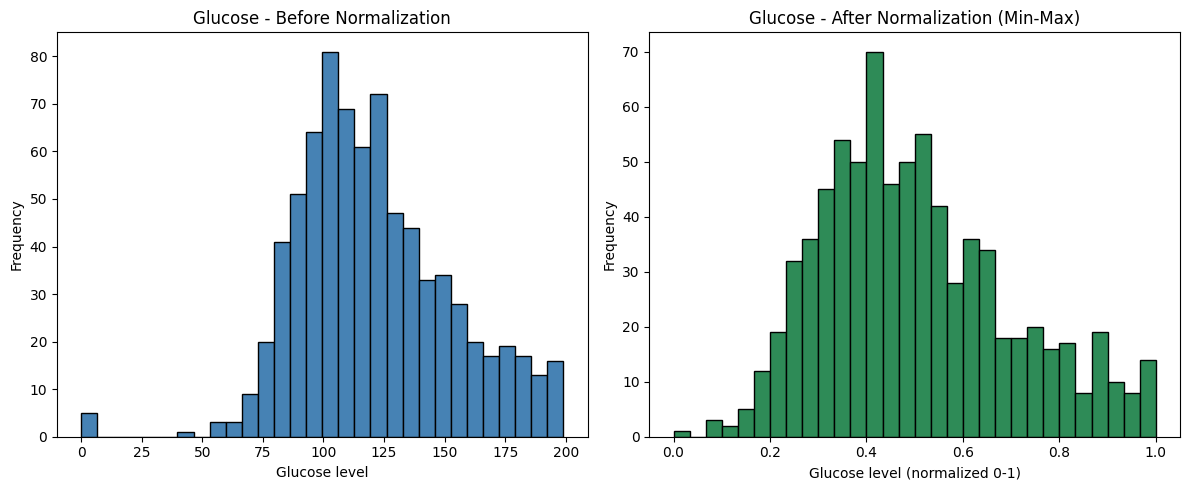

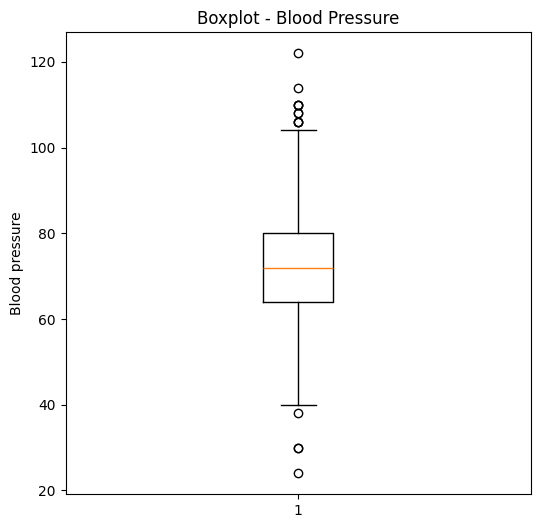

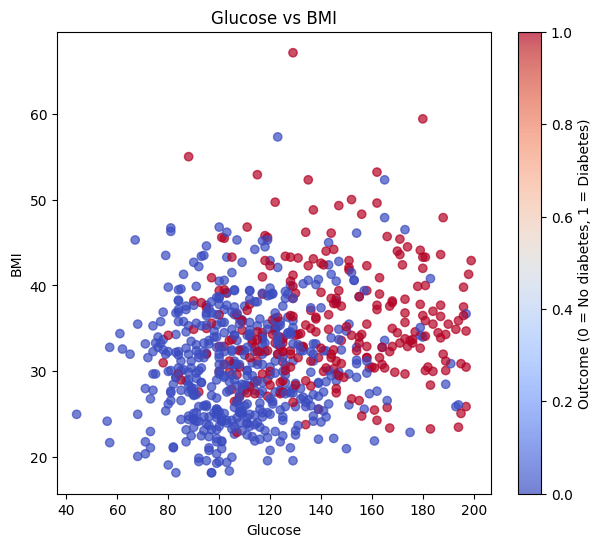

Correlation between Glucose and BMI: 0.231


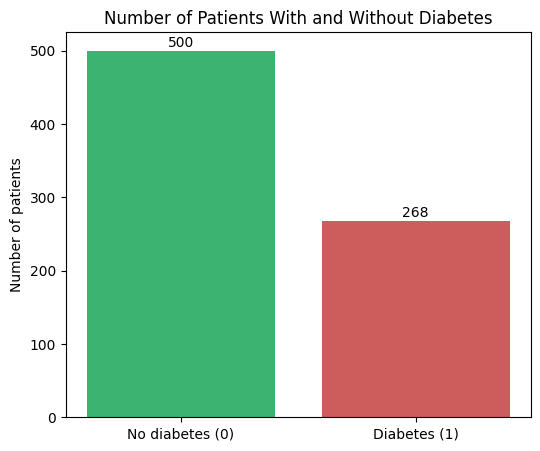

In [1]:
# %% [markdown]
# # Artificial Intelligence - Assignment
# ## Pima Indians Diabetes Dataset Processing
# Team:
# Leonardo Saavedra de León-2093442
# Gilberto Rubén Cabral Martínez- 2110633
# Rocío Gabriela Escalera Mireles-2097046
# Day class: Tuesday
# Hour:N4

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)


# %% [markdown]
# ## Part 1: Data Loading and Exploration

# %%
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)

print("First 5 rows of the dataset:")
print(df.head())

# %%
print("\nDataset info:")
df.info()

# %%
zero_check_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

print("\nCount of 0 values per column:")
for col in zero_check_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

print("\nCount of null (NaN) values per column:")
print(df.isnull().sum())

# %%
print("\nDescriptive statistics:")
print(df.describe())


# %% [markdown]
# ## Part 2: Data Cleaning and Normalization

# %%
df_original = df.copy()
df_clean = df.copy()

for col in zero_check_columns:
    median_value = df_clean.loc[df_clean[col] != 0, col].median()
    df_clean[col] = df_clean[col].replace(0, median_value)

print("Remaining zero values after cleaning:")
for col in zero_check_columns:
    print(f"{col}: {(df_clean[col] == 0).sum()} zeros remaining")

print("\nDescriptive statistics after cleaning:")
print(df_clean.describe())

# %%
columns_to_normalize = df_clean.columns.drop("Outcome")

df_normalized = df_clean.copy()

for col in columns_to_normalize:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    df_normalized[col] = (df_clean[col] - min_val) / (max_val - min_val)

print("First rows of the normalized dataset:")
print(df_normalized.head())

print("\nDescriptive statistics after normalization:")
print(df_normalized.describe())


# %% [markdown]
# ## Part 3: Data Visualization

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_original["Glucose"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Glucose - Before Normalization")
axes[0].set_xlabel("Glucose level")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_normalized["Glucose"], bins=30, color="seagreen", edgecolor="black")
axes[1].set_title("Glucose - After Normalization (Min-Max)")
axes[1].set_xlabel("Glucose level (normalized 0-1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("glucose_histogram.png")
plt.show()

# %%
plt.figure(figsize=(6, 6))
plt.boxplot(df_clean["BloodPressure"], vert=True)
plt.title("Boxplot - Blood Pressure")
plt.ylabel("Blood pressure")
plt.savefig("bloodpressure_boxplot.png")
plt.show()

# %%
plt.figure(figsize=(7, 6))
plt.scatter(
    df_clean["Glucose"],
    df_clean["BMI"],
    c=df_clean["Outcome"],
    cmap="coolwarm",
    alpha=0.7,
)
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.colorbar(label="Outcome (0 = No diabetes, 1 = Diabetes)")
plt.savefig("glucose_bmi_scatter.png")
plt.show()

correlation = df_clean["Glucose"].corr(df_clean["BMI"])
print(f"Correlation between Glucose and BMI: {correlation:.3f}")

# %%
outcome_counts = df_clean["Outcome"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(
    ["No diabetes (0)", "Diabetes (1)"],
    outcome_counts.values,
    color=["mediumseagreen", "indianred"],
)
plt.title("Number of Patients With and Without Diabetes")
plt.ylabel("Number of patients")
for i, value in enumerate(outcome_counts.values):
    plt.text(i, value + 5, str(value), ha="center")
plt.savefig("outcome_bar_chart.png")
plt.show()

# %% [markdown]
# ## Conclusion
#
# The Pima Indians Diabetes dataset was loaded, inconsistent values were
# identified and replaced with the median of each column, numerical data
# was normalized using Min-Max Scaling, and the resulting distributions
# and relationships were visualized. The final dataset (df_normalized) is
# ready to be used in a future Machine Learning model.

What impact do missing values have on data analysis?Missing data reduces the overall statistical power of your study and can distort sample distributions. If missingness is ignored, algorithms might treat a lack of reported information as a real diagnostic signal, leading to biased results—especially if sicker patients are more likely to miss follow-up visits.
How can we detect and handle outliers in biomedical datasets?Outliers in medical data can represent either dangerous hardware errors or rare clinical events. Statistical methods like Z-scores evaluate how far a value strays from the mean, while the Interquartile Range sets boundary thresholds using dataset quartiles. For complex data, multi-dimensional tools like Isolation Forests isolate anomalies across several metrics at once. To handle them safely, you can cap extreme values through Winsorization, filter out biologically impossible numbers, or use robust algorithms that are less sensitive to extreme points.
What are some common causes of missing or incorrect data in biomedical studies?Data issues in healthcare usually stem from four main sources. First, hardware failures like disconnected sensors or signal dropouts can disrupt recordings. Second, operational mistakes occur when clinicians use non-standardized coding or make manual transcription errors. Third, patient non-adherence leads to missed appointments or incomplete logs. Finally, chemical assays sometimes fail to measure values that fall outside standard laboratory detection limits.
How does normalizing data improve the performance of Machine Learning models?Scaling features to a uniform range prevents variables with naturally larger numbers from overwhelming smaller ones. In distance-based algorithms like K-Nearest Neighbors, normalization ensures every variable contributes equally to distance calculations. For neural networks, it prevents erratic optimization steps, leading to faster and smoother convergence during training. It also ensures that regularization penalties treat all features fairly rather than punishing larger scales.
Why is visualizing data an important step before applying Machine Learning models?Visualizing data before training models helps reveal patterns, distributions, and hidden errors that basic summary statistics might miss. Exploratory Data Analysis allows you to uncover structural skewness, spot data leakage, and select the best model architecture for your specific dataset.
Why is preprocessing critical when working with medical datasets?Data preprocessing is a vital first step in biomedical data science because clinical information is often noisy, incomplete, and highly sensitive. Proper handling ensures that your models remain reliable, statistically accurate, and safe for clinical use. Medical datasets often contain wide variations and inconsistent formatting across different patients, so skipping preprocessing leads to biased predictions, inaccurate diagnoses, and models that fail when applied in real clinical settings.
What ethical concerns should be considered when handling patient data?Handling clinical records requires strict adherence to ethical principles. Patients must give informed consent regarding how their information will be used and shared. Data must be anonymized using secure techniques to prevent re-identification, ensuring compliance with privacy laws. Finally, developers must ensure training data is diverse so models do not inherit demographic biases that could harm underrepresented patient groups.